# Wind forcing

**What this shows:** how to create XBeach wind forcing from gridded, station and
single-point data, and how to make sure XBeach uses it.

**Prerequisites:** [Tutorial 4: Adding forcing](../tutorial/04_forcing.ipynb).

**You will learn:**

- how `WindGrid`, `WindStation` and `WindPoint` extract a wind timeseries
- how to describe wind as u/v components or as speed and direction
- how the extraction location and station interpolation work
- why wind must also be switched on in `Physics`

**Data used:** `era5-20230101.nc` (ERA5 winds), `smc-params-20230101.nc` (winds at
wave model sites) and `wind.csv` (a timeseries).

## Setup

In [1]:
import shutil
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy_xbeach.grid import RegularGrid

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "wind"
shutil.rmtree(OUT_DIR, ignore_errors=True)
OUT_DIR.mkdir(parents=True)

grid = RegularGrid(
    ori={"x": 115.594239, "y": -32.641104, "crs": 4326},
    alfa=347.0,
    dx=10.0,
    dy=15.0,
    nx=230,
    ny=220,
    crs=28350,
)
period = TimeRange(start="2023-01-01T00", end="2023-01-01T12", interval="1h")


def generate(wind, name):
    """Write the wind file to its own folder and return it as a dataframe."""
    destdir = OUT_DIR / name
    destdir.mkdir()
    params = wind.get(destdir=destdir, grid=grid, time=period)
    print(f"{name}: {params}")
    df = pd.read_csv(
        destdir / params["windfile"],
        sep=r"\s+",
        header=None,
        names=["tsec", "speed", "direction"],
    )
    df.index = period.start + pd.to_timedelta(df.pop("tsec"), unit="s")
    df.index.name = "time"
    return df

## 1. Gridded winds: `WindGrid`

The wind is taken from the grid cell at the model location. `coords` names the
spatial dimensions, and `WindVector` names the u and v variables. XBeach expects
speed and nautical direction, and the conversion is done for you.

In [2]:
from rompy_xbeach.data.wind import WindGrid, WindVector
from rompy_xbeach.source import SourceCRSFile

wind_grid = WindGrid(
    source=SourceCRSFile(uri=DATA_DIR / "era5-20230101.nc", crs=4326),
    coords={"x": "longitude", "y": "latitude"},
    wind_vars=WindVector(u="u10", v="v10"),
)
winds = {"ERA5 grid": generate(wind_grid, "grid")}

grid: {'windfile': 'wind-20230101T000000-20230101T120000.txt'}


## 2. Winds at stations: `WindStation`

Station data has a site dimension and coordinate variables. By default the wind is
interpolated between nearby sites by inverse distance weighting (`sel_method="idw"`).
`sel_method="nearest"` uses the closest site.

In [3]:
from rompy_xbeach.data.wind import WindStation

station_source = SourceCRSFile(uri=DATA_DIR / "smc-params-20230101.nc", crs=4326)
for method in ("idw", "nearest"):
    wind_station = WindStation(
        source=station_source,
        coords={"s": "seapoint"},
        wind_vars=WindVector(u="uwnd", v="vwnd"),
        sel_method=method,
    )
    winds[f"stations ({method})"] = generate(wind_station, f"station_{method}")

station_idw: {'windfile': 'wind-20230101T000000-20230101T120000.txt'}


station_nearest: {'windfile': 'wind-20230101T000000-20230101T120000.txt'}


The map shows the stations around the model at the first time step:

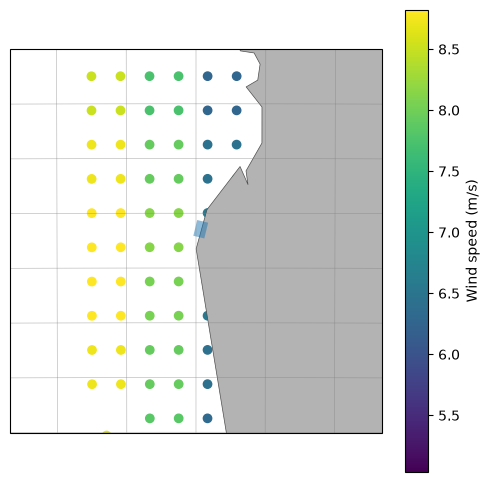

In [4]:
ds = station_source.open().isel(time=0)
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": grid.projection})
speed = (ds.uwnd**2 + ds.vwnd**2) ** 0.5
points = ax.scatter(
    ds.longitude, ds.latitude, c=speed, cmap="viridis", transform=ccrs.PlateCarree()
)
grid.plot(ax=ax, scale="i", set_extent=False, show_origin=False, show_offshore=False)
ax.set_extent([115.2, 116.0, -33.0, -32.3])
fig.colorbar(points, ax=ax, label="Wind speed (m/s)")
plt.show()

## 3. A single timeseries: `WindPoint`

A local record, such as a weather station, is used as it is. `WindScalar` names speed
and direction variables, and `WindVector` would name u and v.

In [5]:
from rompy.core.source import SourceTimeseriesCSV
from rompy_xbeach.data.wind import WindPoint, WindScalar

wind_point = WindPoint(
    source=SourceTimeseriesCSV(filename=DATA_DIR / "wind.csv", tcol="time"),
    wind_vars=WindScalar(spd="wspd", dir="wdir"),
)
winds["CSV point"] = generate(wind_point, "point")

point: {'windfile': 'wind-20230101T000000-20230101T120000.txt'}


Comparing the options:

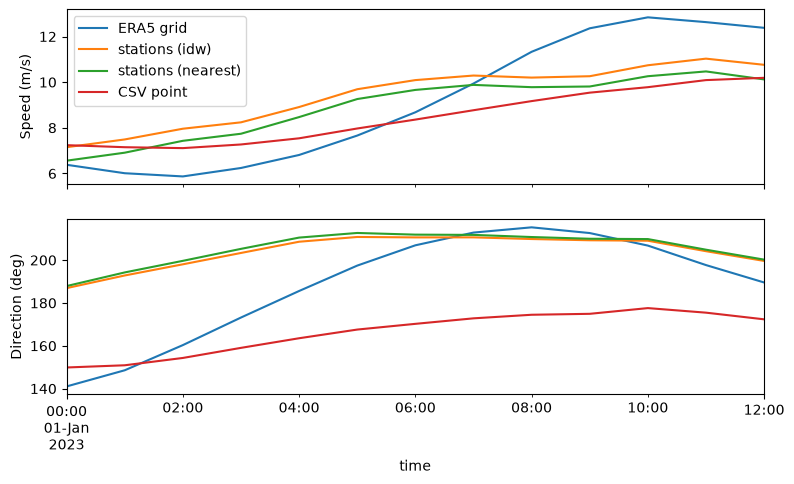

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for label, df in winds.items():
    df.speed.plot(ax=axes[0], label=label)
    df.direction.plot(ax=axes[1], label=label)
axes[0].set_ylabel("Speed (m/s)")
axes[1].set_ylabel("Direction (deg)")
axes[0].legend()
plt.show()

## 4. Where the wind is taken

Gridded and station winds are extracted at the grid centre by default.
`location="offshore"` uses the middle of the offshore boundary instead, which can
matter when winds change quickly towards the coast.

In [7]:
wind_offshore = WindStation(
    source=station_source,
    coords={"s": "seapoint"},
    wind_vars=WindVector(u="uwnd", v="vwnd"),
    location="offshore",
)
winds_offshore = generate(wind_offshore, "station_offshore")
difference = winds_offshore.speed - winds["stations (idw)"].speed
print(f"Mean speed difference, offshore minus centre: {difference.mean():.2f} m/s")

station_offshore: {'windfile': 'wind-20230101T000000-20230101T120000.txt'}
Mean speed difference, offshore minus centre: 0.11 m/s


## 5. Switching wind on

Current XBeach versions ignore the wind file unless wind is enabled in the physics.
Use `Physics(wind=True)`, or the `Wind` component to also set the drag coefficient.

In [8]:
from rompy_xbeach.components.physics import Physics
from rompy_xbeach.components.physics.wavemodel import Surfbeat
from rompy_xbeach.components.physics.wind import Wind

physics = Physics(wavemodel=Surfbeat(), wind=Wind(Cd=0.0015))
physics.get(destdir=None)

{'wavemodel': 'surfbeat', 'wind': 1, 'Cd': 0.0015}

## Summary

| Data | Class | Selection |
|---|---|---|
| Gridded fields | `WindGrid` | Nearest grid cell at `location` |
| Stations | `WindStation` | `idw` or `nearest` at `location` |
| One timeseries | `WindPoint` | None |

Remember to enable wind in `Physics` when adding wind forcing.